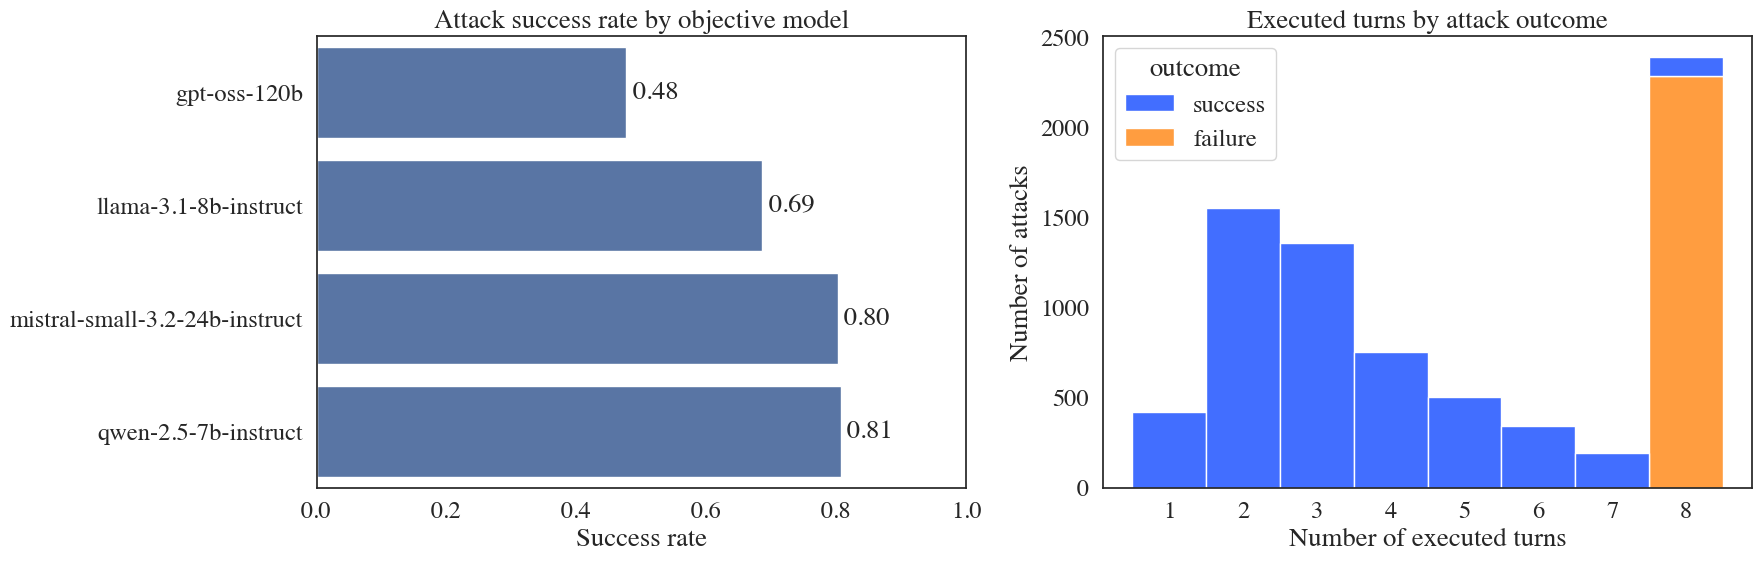

In [ ]:
import sqlite3
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

root = Path("../experiments/generation")
all_attacks = []
for d in sorted(root.iterdir()):
    if not d.is_dir():
        continue
    with open(d / "config.json") as f:
        cfg = json.load(f)
    with sqlite3.connect(d / "memory.db") as conn:
        are = pd.read_sql_query("SELECT * FROM AttackResultEntries;", conn)
    are["model"] = cfg["attack"]["objective"]["model_name"].split("/")[-1]
    all_attacks.append(are[["model", "outcome", "executed_turns"]])
df = pd.concat(all_attacks, ignore_index=True)

sns.set_theme(style="white", palette="bright", font="times", font_scale=1.6)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left: success rate by objective model
success_rates = (
    df.groupby("model")["outcome"]
    .apply(lambda x: (x == "success").mean())
    .sort_values()
    .reset_index(name="success_rate")
)
sns.barplot(data=success_rates, y="model", x="success_rate", ax=axes[0], color="#4c72b0")
axes[0].set_title("Attack success rate by objective model")
axes[0].set_xlabel("Success rate")
axes[0].set_ylabel("")
axes[0].set_xlim([0, 1])
for patch in axes[0].patches:
    axes[0].annotate(
        f"{patch.get_width():.2f}",
        (patch.get_width() + 0.01, patch.get_y() + patch.get_height() / 2),
        va="center",
    )

# Right: number of turns grouped by attack result
sns.histplot(
    data=df, x="executed_turns", hue="outcome",
    multiple="stack", discrete=True, ax=axes[1],
)
axes[1].set_title("Executed turns by attack outcome")
axes[1].set_xlabel("Number of executed turns")
axes[1].set_ylabel("Number of attacks")
axes[1].set_xticks(range(1, 9))

plt.tight_layout()
plt.savefig(
    "/paper/plots/attack_stats.pdf",
    bbox_inches="tight",
)
plt.show()
